Introduction to the Railway Dataset:

This dataset provides structured information about railway stations in India, including details about their zones, divisions, interchanges, station layouts, and distances. The dataset consists of 54 railway stations, with 12 attributes that describe their connectivity and facilities.
->Purpose of the Dataset:
---------------------------
->Railway Planning & Analysis: Helps identify important interchange hubs and station layouts.
->Urban Transport Development: Useful for studying railway connectivity and infrastructure availability.
->Operational Insights: Zones and divisions allow authorities to optimize routes and passenger convenience.

In [2]:
 import pandas as pd

In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
 import pandas as pd
 import matplotlib.pyplot as plt

In [5]:
import pandas as pd
Railway = pd.read_csv(r"C:\Users\valla\Downloads\Railway Data.csv", encoding='cp1252')
print(Railway.head())

      City  Zone  Division  Connection  \
0  Chennai     5        60  South Line   
1  Chennai     5        60  South Line   
2  Chennai     5        58  South Line   
3  Chennai     5        61  South Line   
4  Chennai     8       104  South Line   

                                         Interchange  \
0                   North Line; West Line; MRTS Line   
1                                          MRTS Line   
2  North Line; West Line; MRTS Line; CMRL Blue; C...   
3                                    CMRL Green Line   
4                                                 No   

                            Station Station Code  Distance in Kms    Layout  \
0                  Chennai Beach RS          MSB             0.00  At Grade   
1                   Chennai Fort RS          MSF             1.80  At Grade   
2  Chennai Park RS; Chennai Central          MPK             3.07  At Grade   
3  Chennai Egmore RS; Rail Terminus           MS             4.32  At Grade   
4              

In [6]:
Railway.shape

(54, 12)

# IT SHOWS A SHAPE LIKE ROWS AND COLUMN

In [7]:
Railway.isnull()

,City,Zone,Division,Connection,Interchange,Station,Station Code,Distance in Kms,Layout,Parking Contract Available,Space Avaiable No Contract,Sapce Not Avaiable
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False


# TO FIND NULL VALUE IN THE RAILWAY DATA SET

In [8]:
print(Railway.describe())

            Zone    Division  Distance in Kms
count  54.000000   54.000000        54.000000
mean    7.592593   96.111111         8.658407
std     3.652440   53.659889         6.052165
min     1.000000    2.000000         0.000000
25%     5.000000   58.250000         3.572500
50%     7.000000   83.500000         8.075000
75%    10.000000  140.500000        13.572000
max    14.000000  189.000000        21.220000


# THE BASIC STATISTIC OF RAILWAY DATA SET

In [9]:
zone_distance = Railway.groupby('Zone')['Distance in Kms'].mean()
print(zone_distance)

Zone
1     12.885000
4      5.216667
5      1.657333
6      6.000000
7     13.666667
8      7.280000
9      7.725500
10    12.095000
12    18.428000
13    13.650000
14    17.955000
Name: Distance in Kms, dtype: float64


# IT CAN BE CALCULATE THE MEAN AND ZONE DISTANCES OF RAILWAY DATA SET

In [50]:
print("Duplicate Rows: ", Railway.duplicated().sum())
Railway.drop_duplicates(inplace=True)

Duplicate Rows:  0


In [52]:
Railway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   City                        54 non-null     object 
 1   Zone                        54 non-null     int64  
 2   Division                    54 non-null     int64  
 3   Connection                  54 non-null     object 
 4   Interchange                 54 non-null     object 
 5   Station                     54 non-null     object 
 6   Station Code                54 non-null     object 
 7   Distance in Kms             54 non-null     float64
 8   Layout                      54 non-null     object 
 9   Parking Contract Available  50 non-null     object 
 10  Space Avaiable No Contract  50 non-null     object 
 11  Sapce Not Avaiable          50 non-null     object 
 12  Interchange Count           54 non-null     int64  
 13  Station Sequence            54 non-nu

In [53]:
print(Railway.columns)

Index(['City', 'Zone', 'Division', 'Connection', 'Interchange', 'Station',
       'Station Code', 'Distance in Kms', 'Layout',
       'Parking Contract Available', 'Space Avaiable No Contract',
       'Sapce Not Avaiable', 'Interchange Count', 'Station Sequence'],
      dtype='object')


In [54]:
print(Railway.isnull().sum())
Railway = Railway.dropna(axis=1, thresh=len(Railway) * 0.5)

City                          0
Zone                          0
Division                      0
Connection                    0
Interchange                   0
Station                       0
Station Code                  0
Distance in Kms               0
Layout                        0
Parking Contract Available    4
Space Avaiable No Contract    4
Sapce Not Avaiable            4
Interchange Count             0
Station Sequence              0
dtype: int64


In [11]:
Railway['Interchange Count'] = Railway['Interchange'].apply(lambda x: len(x.split(';')))
print(Railway[['Station', 'Interchange Count']])

                             Station  Interchange Count
0                   Chennai Beach RS                  3
1                    Chennai Fort RS                  1
2   Chennai Park RS; Chennai Central                  5
3   Chennai Egmore RS; Rail Terminus                  1
4                         Chetpat RS                  1
5                    Nungambakkam RS                  1
6                     Kodambakkam RS                  1
7              Mambalam RS; T Nagar                   1
8                        Saidapet RS                  1
9                          Guindy RS                  1
10                St Thomas Mount RS                  1
11                 Palavanthangal RS                  1
12                    Minambakkam RS                  1
13             Tirusulam RS; Airport                  1
14                  Chennai Beach RS                  3
15                     Royapuram RS                   1
16                   Washermanpet RS            

# HERE TO COUNT THE NUMBER OF INTERCHANGES OF EACH STATION IN RAILWAY DATA SET

In [12]:
 division_count = Railway['Division'].value_counts()
print(division_count)

Division
60     5
58     3
175    3
124    2
59     2
38     2
53     2
52     2
159    2
121    1
116    1
96     1
126    1
173    1
114    1
180    1
184    1
85     1
84     1
83     1
179    1
65     1
70     1
69     1
160    1
61     1
104    1
110    1
117    1
136    1
142    1
161    1
71     1
162    1
47     1
7      1
4      1
3      1
2      1
189    1
Name: count, dtype: int64


# HERE WE HAVE TO COUNT THE STATIONS BY DIVISION 

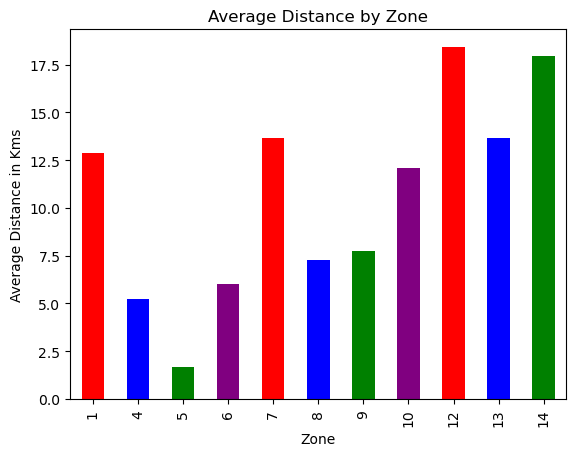

In [51]:
zone_distance.plot(kind='bar', title='Average Distance by Zone', color=['red', 'blue', 'green', 'purple'])
plt.xlabel('Zone')
plt.ylabel('Average Distance in Kms')
plt.show()

# HERE TO FIND THE PLOT OF AVERAGE DISTANCE BY ZONE

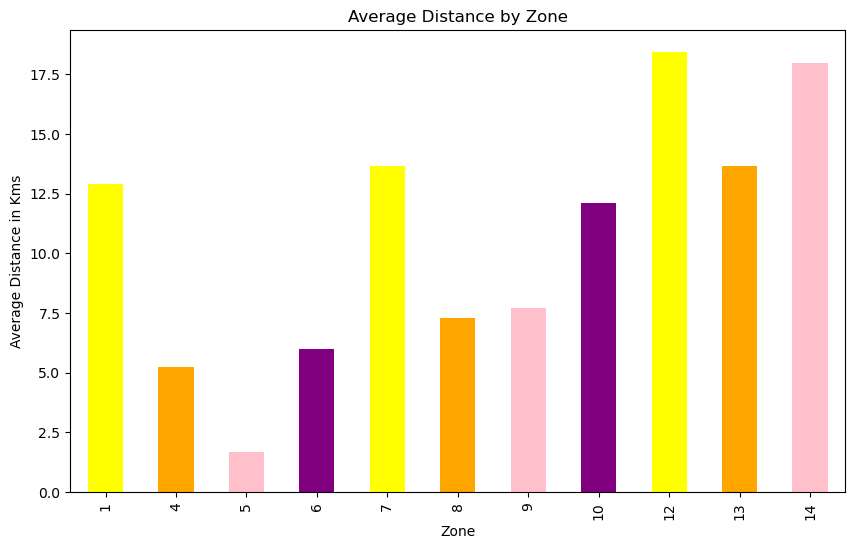

In [18]:
plt.figure(figsize=(10, 6))
zone_distance.plot(kind='bar', title='Average Distance by Zone', color=['yellow', 'orange', 'pink', 'purple'])
plt.xlabel('Zone')
plt.ylabel('Average Distance in Kms')
plt.show()

# HERE WE HAVE TO PLOT THE AVERAGE DISTANCE OF ZONE IN THE RAILWAY DATA SET

Layout
At Grade    40
Elevated    14
Name: count, dtype: int64


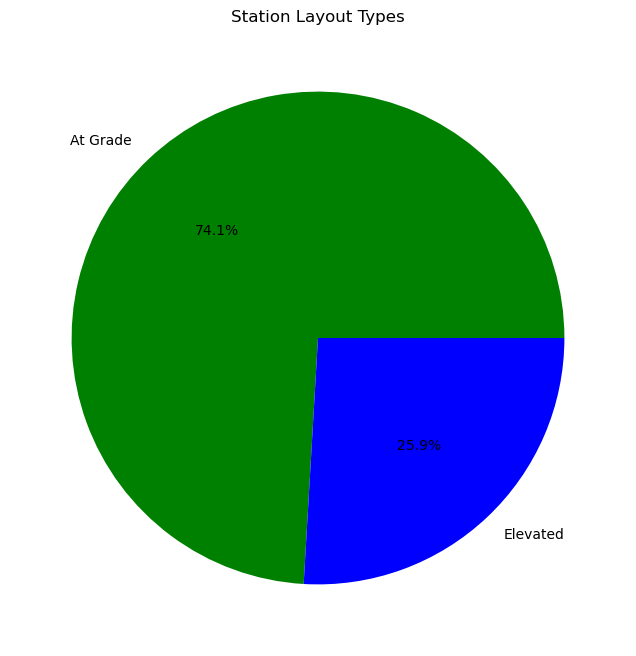

In [22]:
layout_distribution = Railway['Layout'].value_counts()
print(layout_distribution)
plt.figure(figsize=(8, 8))
layout_distribution.plot(kind='pie', autopct='%1.1f%%', title='Station Layout Types', colors=['green', 'blue', 'green', 'purple', 'orange'])
plt.ylabel('')
plt.show()

# HERE TO SHOW THW PIE CHART OF THE STATIONS LAYOUT OF RAILWAY DATA SETS 

City
Chennai    54
Name: count, dtype: int64


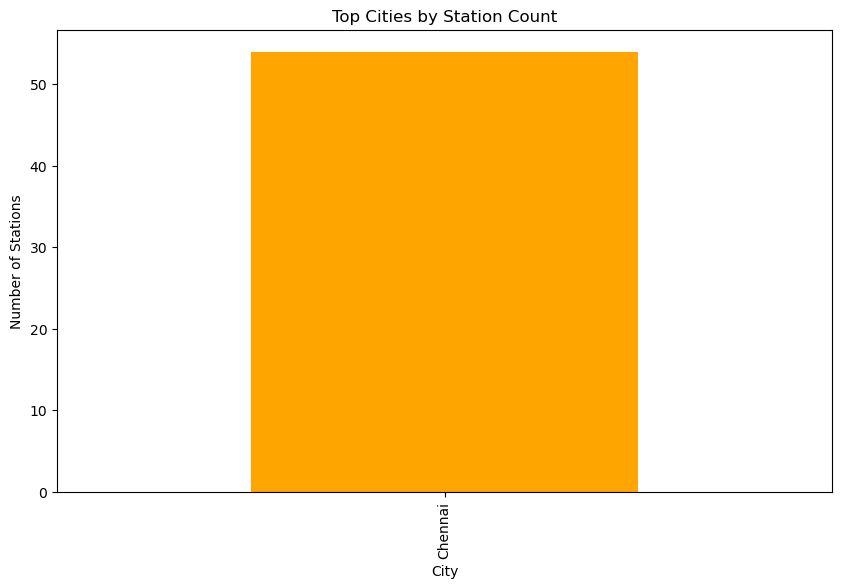

In [23]:
top_cities = Railway['City'].value_counts().head(5)
print(top_cities)
plt.figure(figsize=(10, 6))
top_cities.plot(kind='bar', title='Top Cities by Station Count', color='orange')
plt.xlabel('City')
plt.ylabel('Number of Stations')
plt.show()

# TO PLOT THE CITIES OF THE STATION BY THE USE OF RAILWAY DTATA SET

Division
60     5
58     3
175    3
124    2
59     2
38     2
53     2
52     2
159    2
121    1
116    1
96     1
126    1
173    1
114    1
180    1
184    1
85     1
84     1
83     1
179    1
65     1
70     1
69     1
160    1
61     1
104    1
110    1
117    1
136    1
142    1
161    1
71     1
162    1
47     1
7      1
4      1
3      1
2      1
189    1
Name: count, dtype: int64


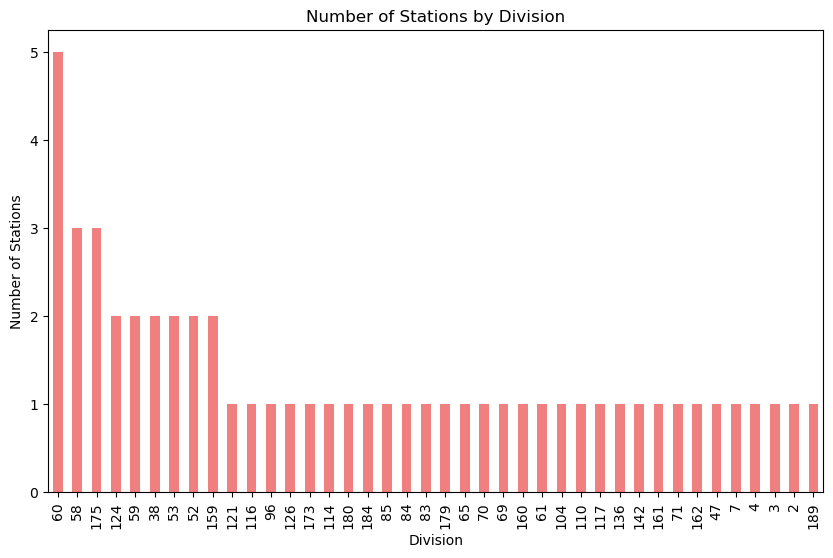

In [24]:
import matplotlib.pyplot as plt
division_count = Railway['Division'].value_counts()
print(division_count)
plt.figure(figsize=(10, 6))
division_count.plot(kind='bar', color='lightcoral')
plt.title('Number of Stations by Division')  
plt.xlabel('Division')
plt.ylabel('Number of Stations')
plt.show()

# HERE WE HAVE TO PLOT THE COUNT OF STATIONS IN RAILWAY DATA SET

C:\Users\valla\AppData\Local\Temp\ipykernel_22300\2740182959.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Station', y='Interchange Count', data=Railway, palette='viridis')


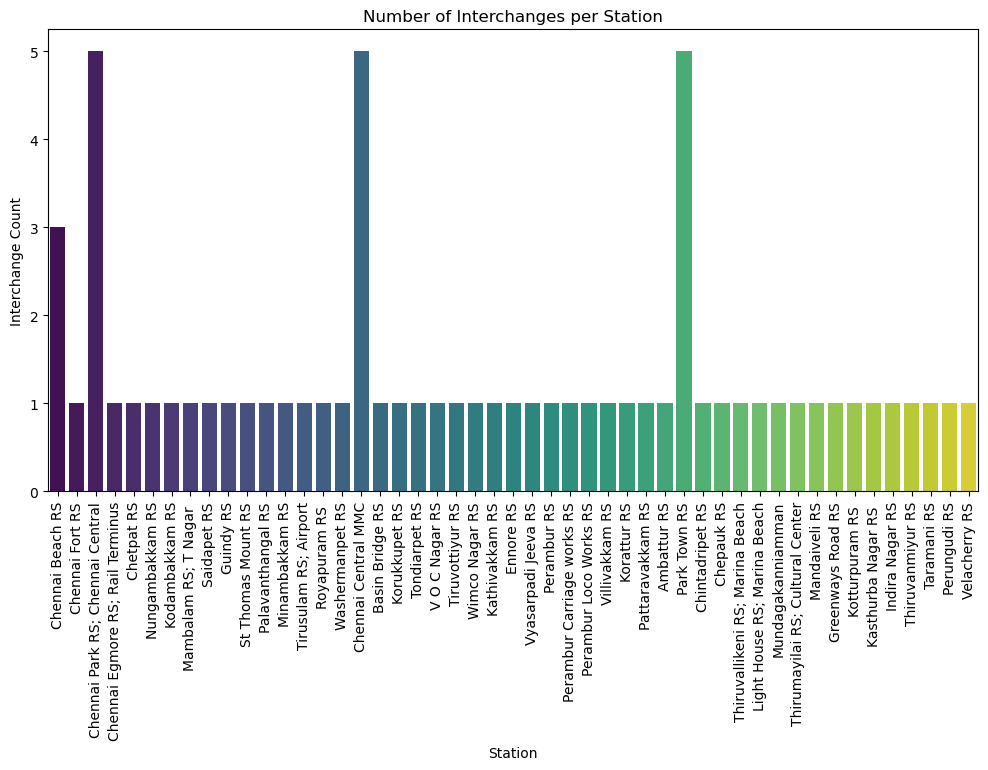

Column 'Interchange' not found in the dataset.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
Railway['Interchange Count'] = Railway['Interchange'].apply(lambda x: len(x.split(';')) if isinstance(x, str) else 0)
plt.figure(figsize=(12, 6))
sns.barplot(x='Station', y='Interchange Count', data=Railway, palette='viridis')
plt.title('Number of Interchanges per Station')
plt.xticks(rotation=90)
plt.show()
print("Column 'Interchange' not found in the dataset.")

# HERE WE HAVE TO COUNT THE INTERCHANGES OF EACH STATION OF RAILWAY DTATA SET

<Figure size 1000x600 with 0 Axes>

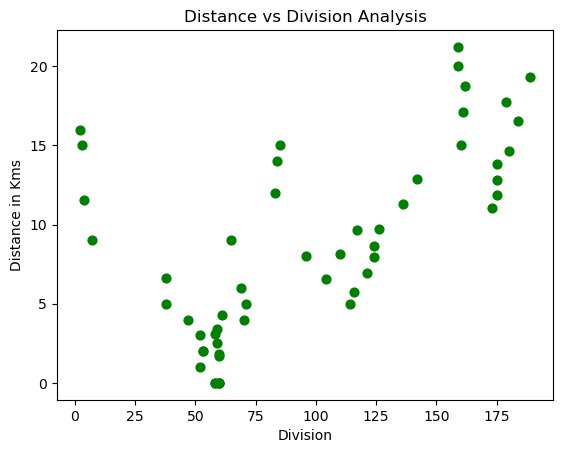

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
Railway.plot.scatter(x='Division', y='Distance in Kms', color='green', s=40)
plt.title("Distance vs Division Analysis")
plt.xlabel('Division')
plt.ylabel('Distance in Kms')
plt.show()

<Figure size 1000x600 with 0 Axes>

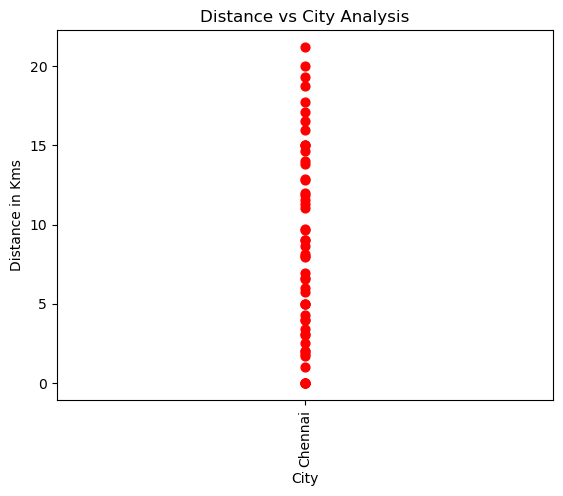

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
Railway.plot.scatter(x='City', y='Distance in Kms', color='red', s=40)
plt.title("Distance vs City Analysis")
plt.xlabel('City')
plt.ylabel('Distance in Kms')
plt.xticks(rotation=90)
plt.show()

<Figure size 1000x600 with 0 Axes>

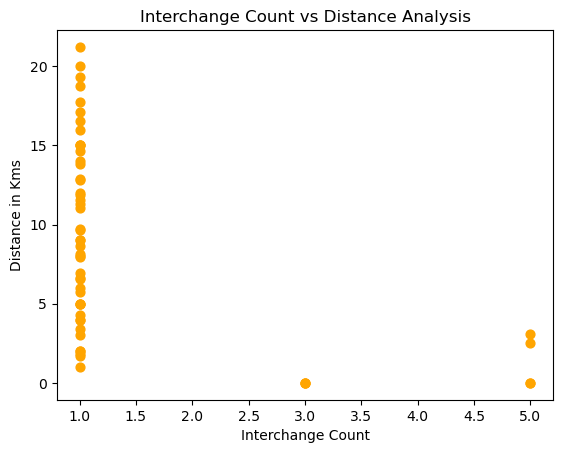

In [28]:
plt.figure(figsize=(10, 6))
Railway.plot.scatter(x='Interchange Count', y='Distance in Kms', color='orange', s=40)
plt.title("Interchange Count vs Distance Analysis")
plt.xlabel('Interchange Count')
plt.ylabel('Distance in Kms')
plt.show()

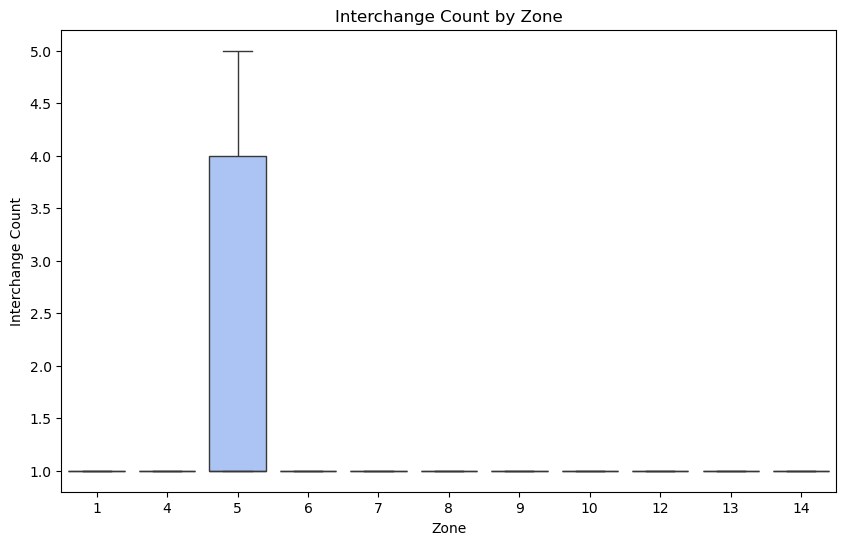

In [29]:
Railway['Interchange Count'] = Railway['Interchange'].apply(lambda x: len(x.split(';')))
plt.figure(figsize=(10, 6))
sns.boxplot(x='Zone', y='Interchange Count', data=Railway, palette='coolwarm', hue='Zone', legend=False)
plt.title("Interchange Count by Zone")
plt.xlabel("Zone")
plt.ylabel("Interchange Count")
plt.show()

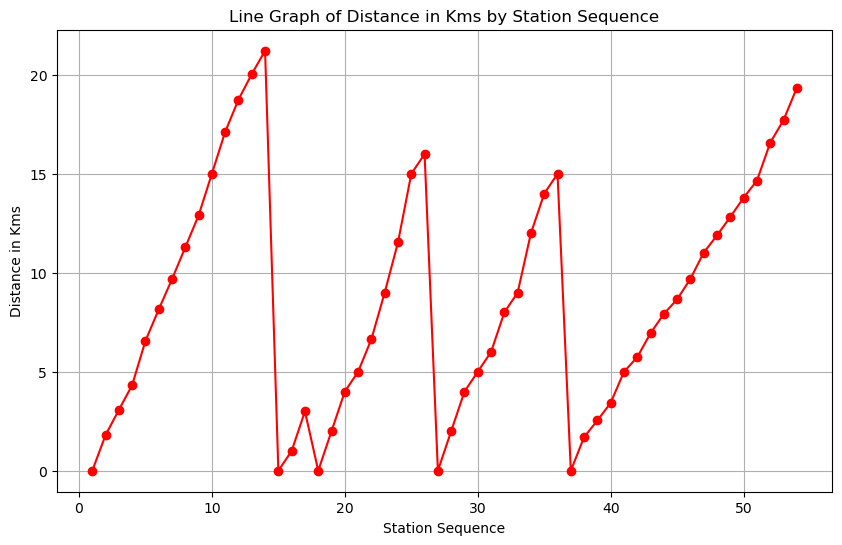

In [30]:
Railway['Station Sequence'] = range(1, len(Railway) + 1)
plt.figure(figsize=(10, 6))
plt.plot(Railway['Station Sequence'], Railway['Distance in Kms'], color='red', marker='o')
plt.title("Line Graph of Distance in Kms by Station Sequence")
plt.xlabel("Station Sequence")
plt.ylabel("Distance in Kms")
plt.grid(True)
plt.show()

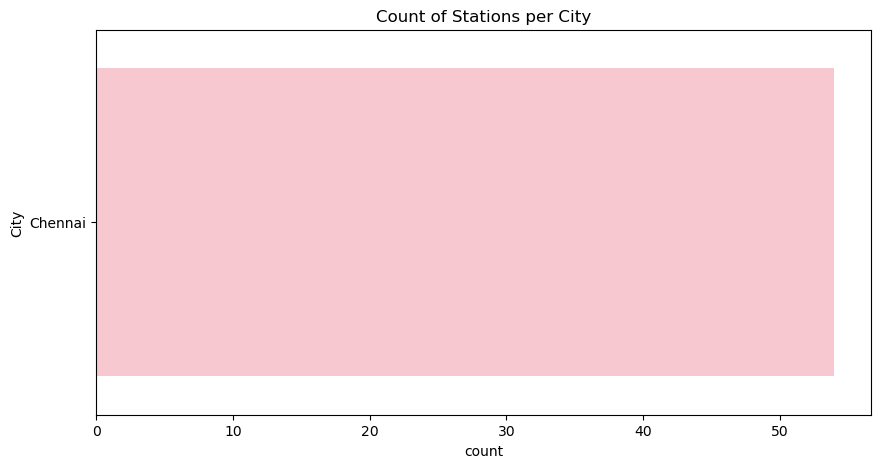

In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(y=Railway['City'],color='pink', order=Railway['City'].value_counts().index)
plt.title("Count of Stations per City")
plt.show()

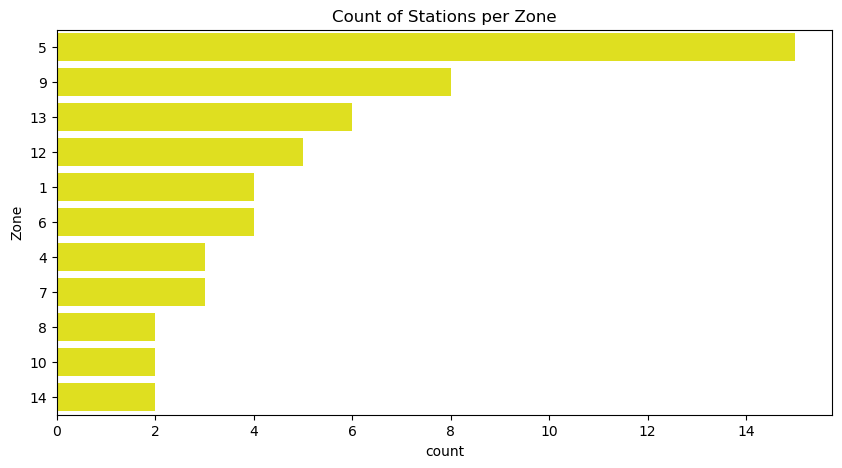

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(y=Railway['Zone'],color='yellow', order=Railway['Zone'].value_counts().index)
plt.title("Count of Stations per Zone")
plt.show()

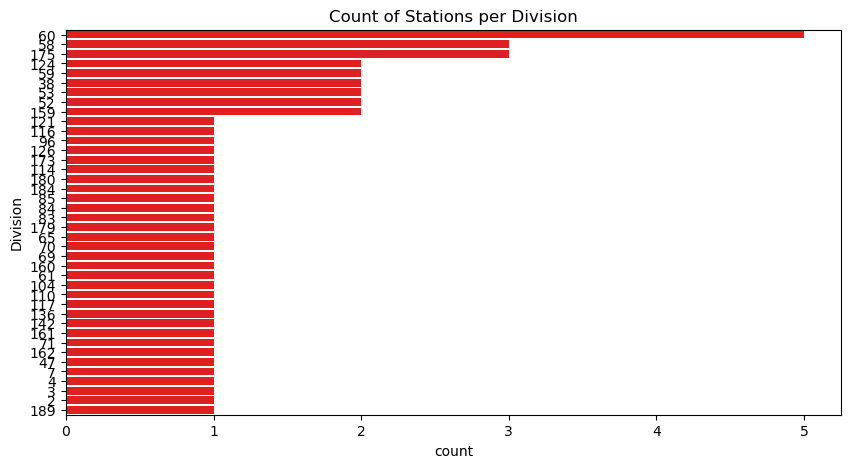

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(y=Railway['Division'],color='red', order=Railway['Division'].value_counts().index)
plt.title("Count of Stations per Division")
plt.show()


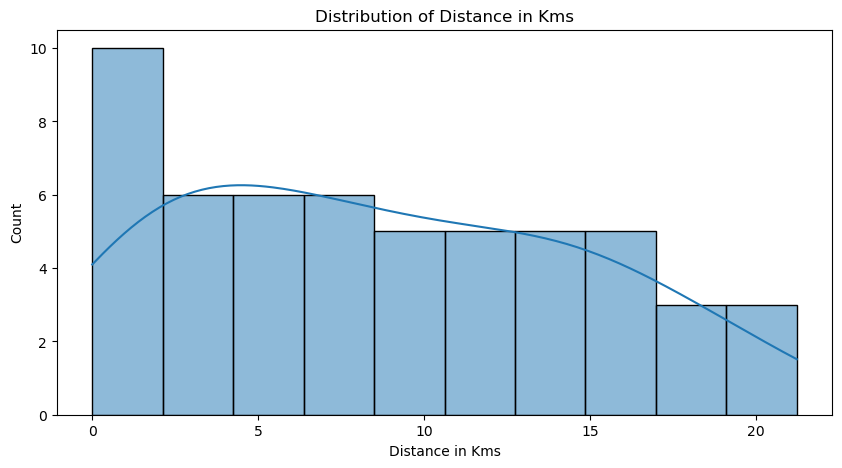

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(Railway['Distance in Kms'], bins=10, kde=True)
plt.title("Distribution of Distance in Kms")
plt.show()

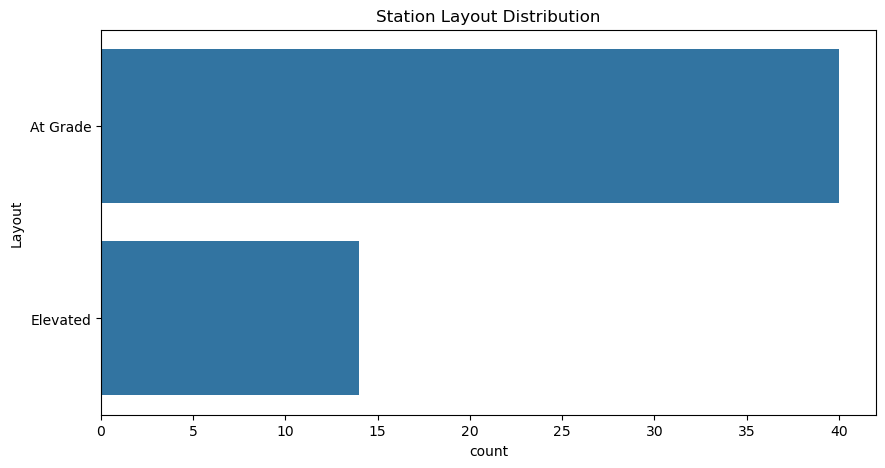

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(y=Railway['Layout'], order=Railway['Layout'].value_counts().index)
plt.title("Station Layout Distribution")
plt.show()

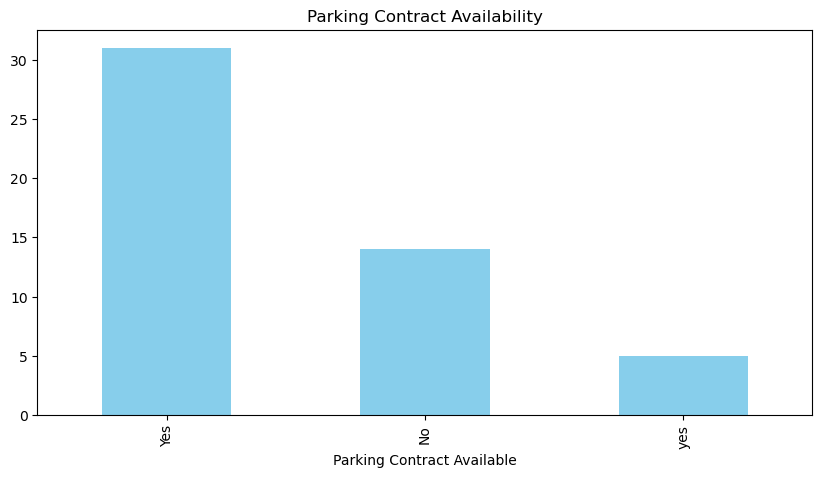

In [37]:
plt.figure(figsize=(10, 5))
Railway['Parking Contract Available'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Parking Contract Availability")
plt.show()

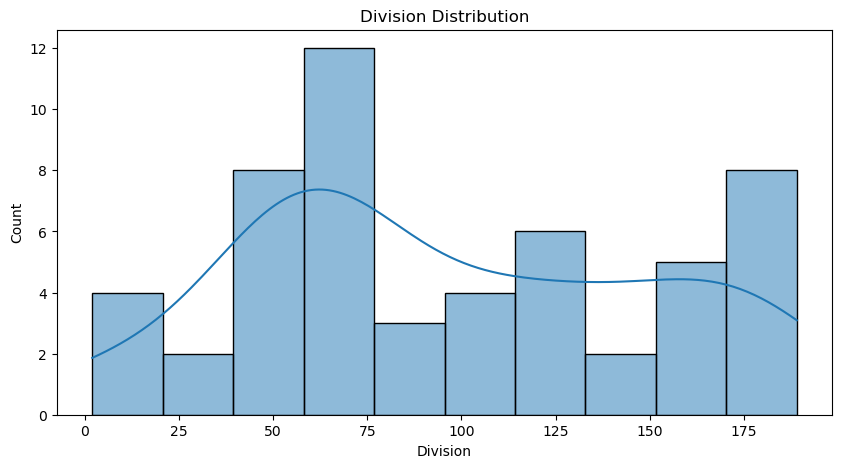

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(Railway['Division'], kde=True, bins=10)
plt.title("Division Distribution")
plt.show()

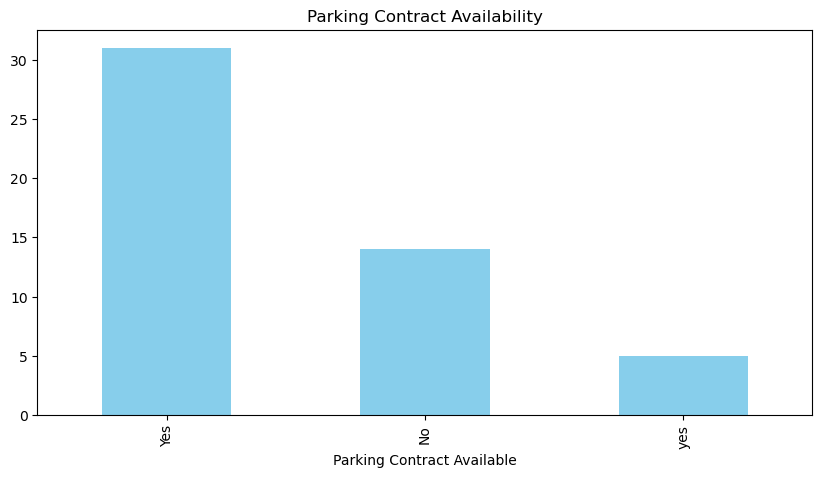

In [39]:
plt.figure(figsize=(10, 5))
Railway['Parking Contract Available'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Parking Contract Availability")
plt.show()

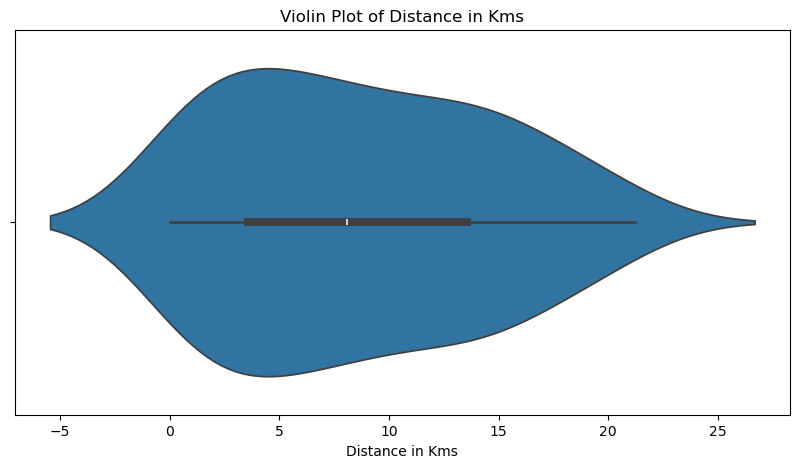

In [40]:
plt.figure(figsize=(10, 5))
sns.violinplot(x=Railway['Distance in Kms'])
plt.title("Violin Plot of Distance in Kms")
plt.show()

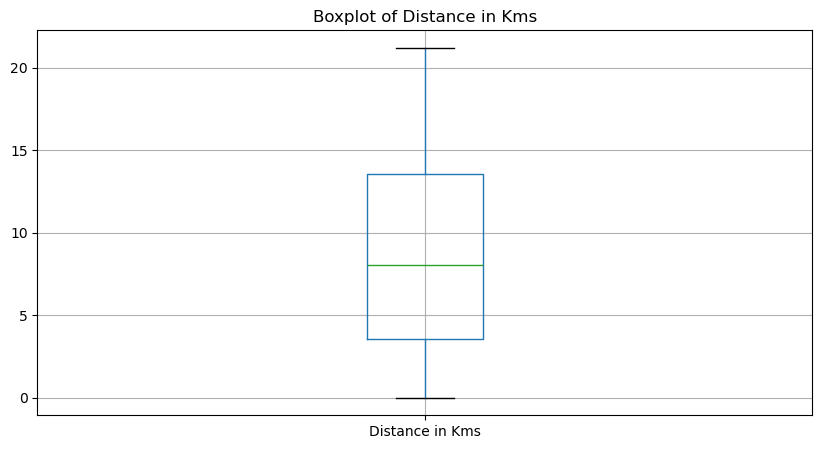

In [41]:

plt.figure(figsize=(10, 5))
Railway.boxplot(column=['Distance in Kms'])
plt.title("Boxplot of Distance in Kms")
plt.show()

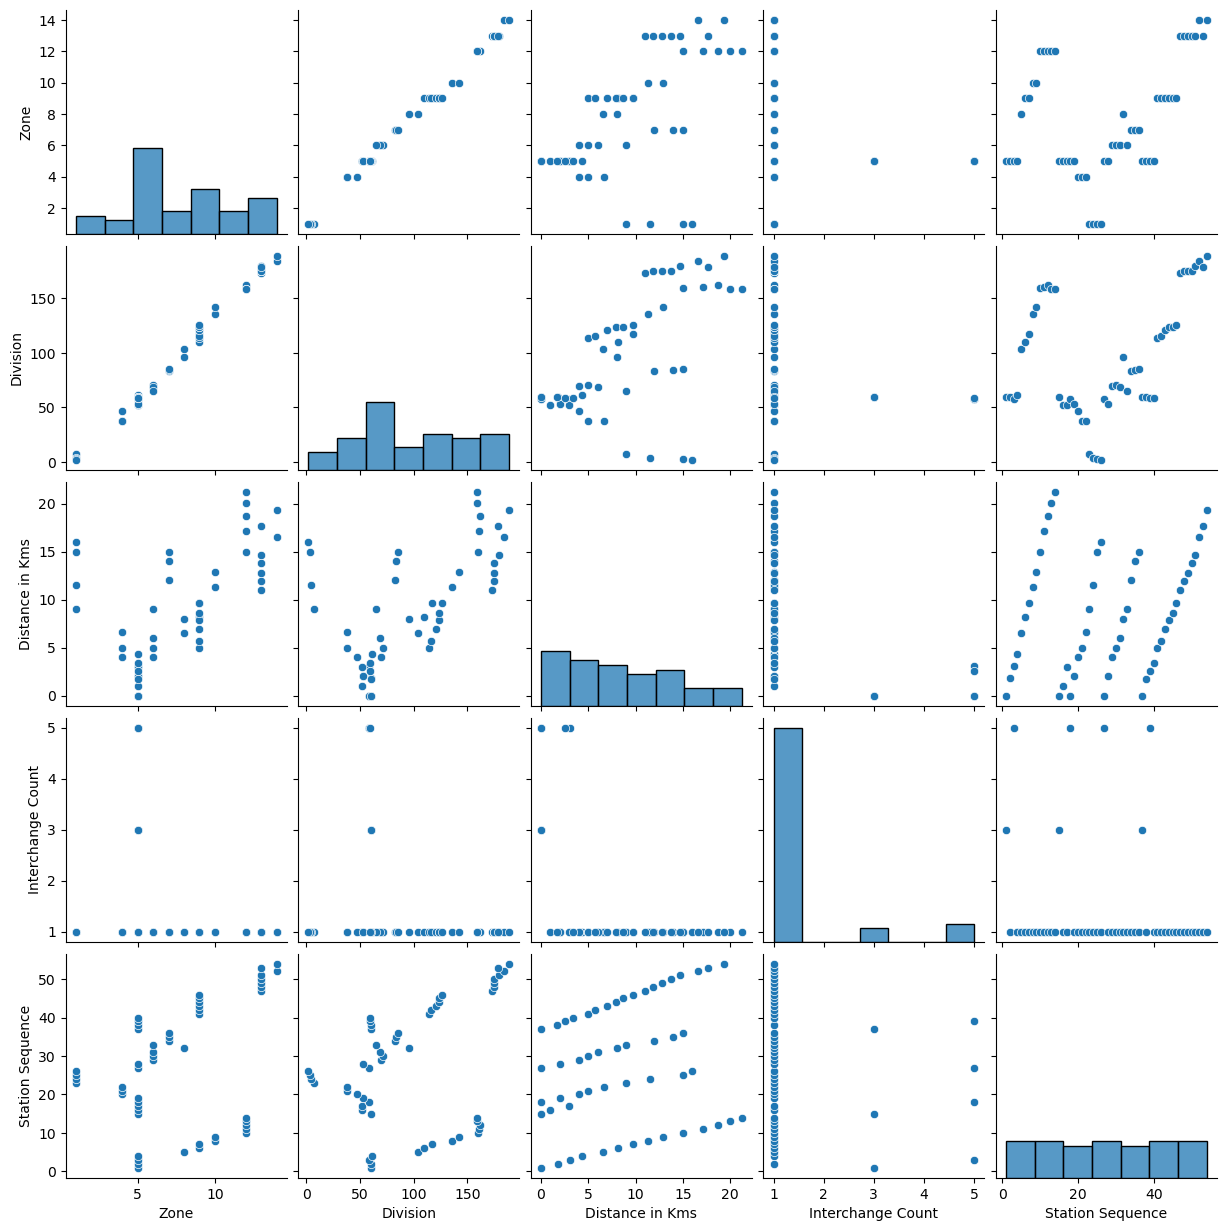

In [43]:
sns.pairplot(Railway.select_dtypes(include=['int64', 'float64']))
plt.show()

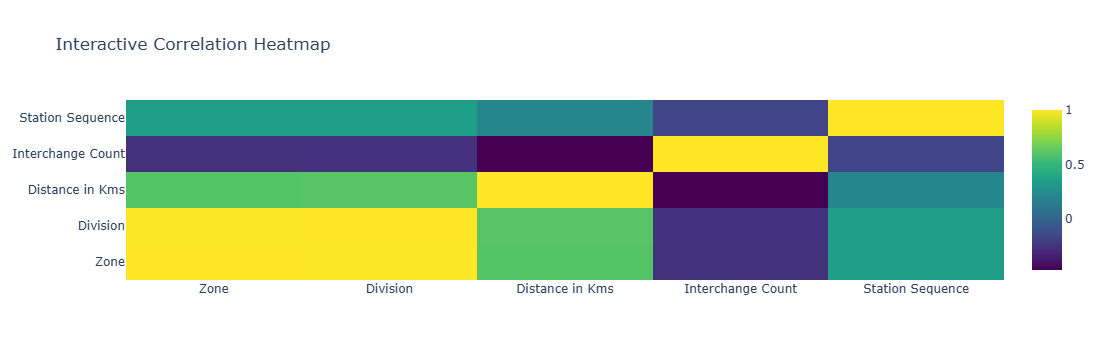

In [44]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Heatmap(z=Railway.corr(numeric_only=True).values,
                                 x=Railway.corr(numeric_only=True).columns,
                                 y=Railway.corr(numeric_only=True).columns,
                                 colorscale='Viridis')])
fig.update_layout(title='Interactive Correlation Heatmap')
fig.show()


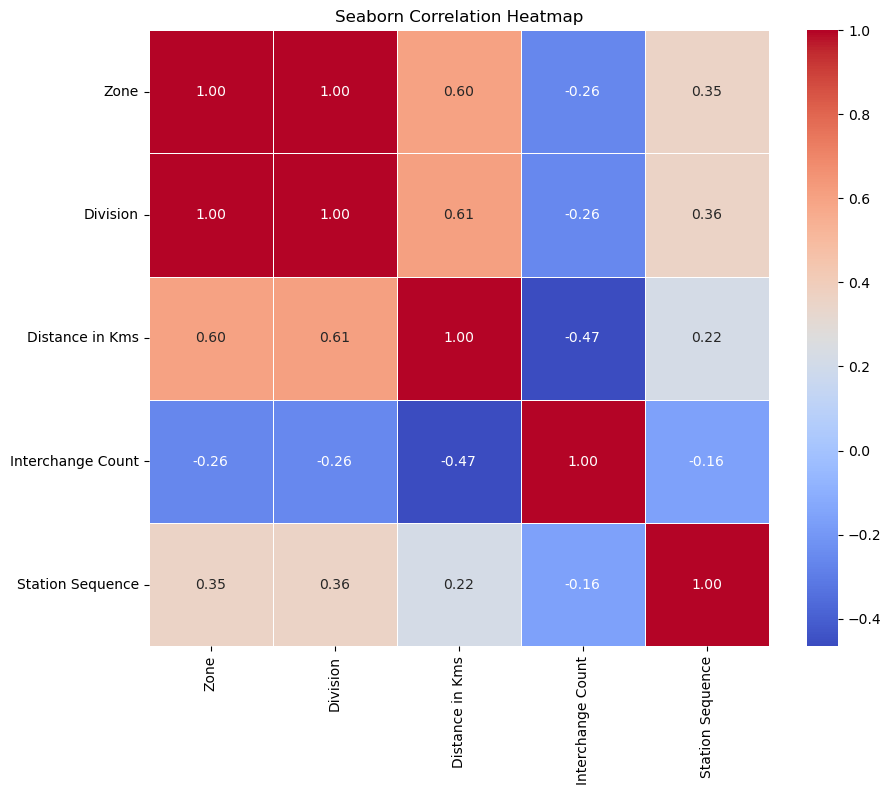

In [45]:
plt.figure(figsize=(10, 8))
corr_matrix = Railway.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Seaborn Correlation Heatmap")
plt.show()

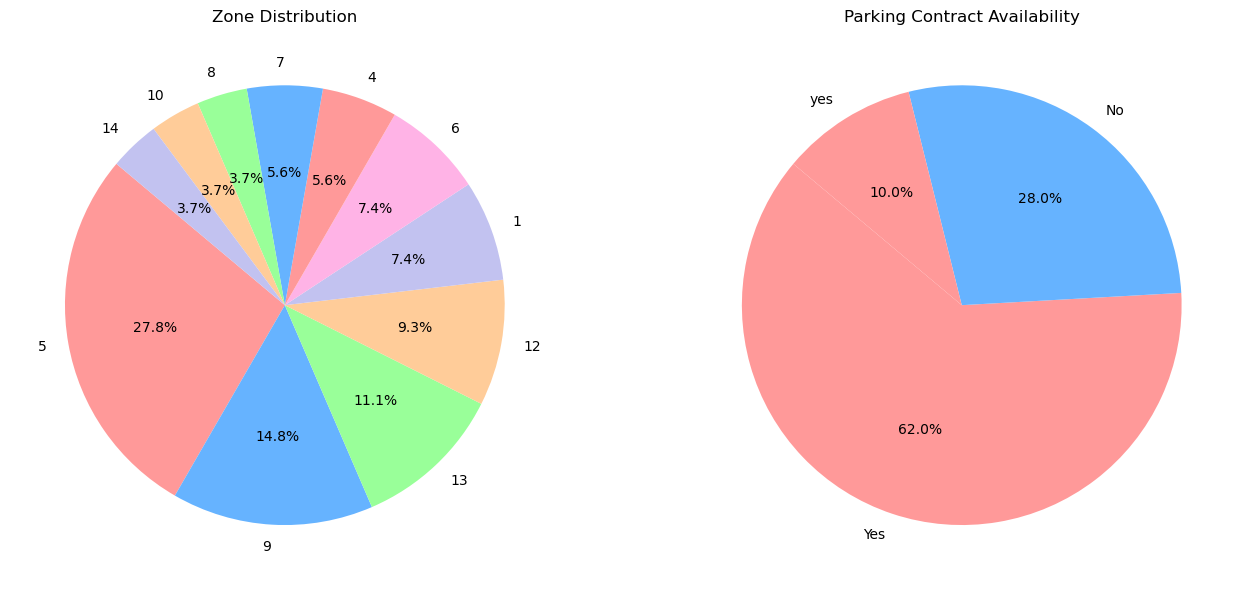

In [49]:
zone_counts = Railway['Zone'].value_counts()
parking_counts = Railway['Parking Contract Available'].dropna().value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(zone_counts, labels=zone_counts.index, autopct='%1.1f%%', startangle=140, 
            colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6'])
axes[0].set_title('Zone Distribution')
axes[1].pie(parking_counts, labels=parking_counts.index, autopct='%1.1f%%', startangle=140, 
            colors=['#ff9999','#66b3ff'])
axes[1].set_title('Parking Contract Availability')
plt.tight_layout()
plt.show()

# Conclusion about the Railway Dataset:
# 1. Data Overview
# ->The dataset contains railway station details, including Zone, Distance, Division, Layout, and Interchanges.
# ->Summary statistics (describe()) helped analyze numerical columns.And Missing values were checked and handled.
# 2. Data Cleaning
# ->Checked for and processed missing values.
# ->Converted the Interchange column into a numerical count for better analysis.
# ->Ensured proper encoding (cp1252) while loading the dataset.
# 3. Data Visualization & Insights
# ->3.1 Average Distance by Zone
# *Stations were grouped by Zone, and the average travel distance was calculated.
# *Displayed using a bar chart with different colors for each bar.
# ->3.2 Interchange Count
# *The number of interchanges at each station was counted.
# *This helps identify major hub stations with high connectivity.
# ->3.3 Division Distribution
# *Counted the number of stations under each Railway Division.
# *Used a bar plot to visualize the station distribution across divisions.
# *3.4 Station Layout Distribution
# *Used a pie chart to show the percentage of different station layouts.
# *This helps understand the most common station designs in the railway network.
# 4. Conclusion
# ->The dataset provides valuable insights into railway station layouts, travel distances, and interchanges.
# ->Major zones with high average distances indicate longer travel routes.
# ->High interchange counts highlight important railway hubs.
# ->Division-wise analysis shows how stations are distributed across different administrative regions.
# ->This analysis can be extended by integrating additional datasets or refining visualizations further.